In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img

# pre_trained model packages
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions
from tensorflow.keras.preprocessing.image import ImageDataGenerator 

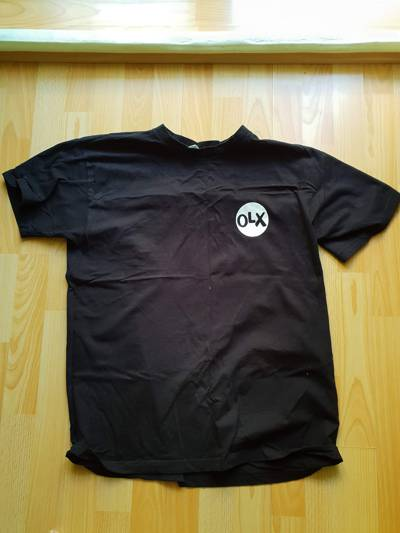

In [2]:
path = './clothing-dataset-small-master/train/t-shirt'
name = '5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg'
fullname = f'{path}/{name}'
load_img(fullname)

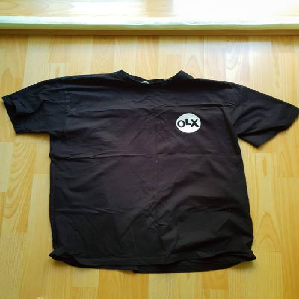

In [3]:
img = load_img(fullname, target_size=(299, 299, 3))
img

# Pre-trained convolutional neural networks

- Imagenet dataset: https://www.image-net.org/
- Pre-trained models: https://keras.io/api/applications/

In [4]:
model = Xception(weights='imagenet', input_shape=(299, 299, 3))

In [5]:
x = np.array(img)
x.shape

(299, 299, 3)

In [6]:
X = np.array([x])
X.shape

(1, 299, 299, 3)

In [7]:
X = preprocess_input(X)

In [8]:
X

array([[[[ 0.4039216 ,  0.3411765 , -0.2235294 ],
         [ 0.4039216 ,  0.3411765 , -0.2235294 ],
         [ 0.41960788,  0.35686278, -0.20784312],
         ...,
         [ 0.96862745,  0.9843137 ,  0.94509804],
         [ 0.96862745,  0.9843137 ,  0.94509804],
         [ 0.96862745,  0.99215686,  0.9372549 ]],

        [[ 0.47450984,  0.4039216 , -0.12156862],
         [ 0.4666667 ,  0.39607847, -0.12941176],
         [ 0.45882356,  0.38823533, -0.15294117],
         ...,
         [ 0.96862745,  0.9764706 ,  0.9372549 ],
         [ 0.96862745,  0.9764706 ,  0.9372549 ],
         [ 0.96862745,  0.9764706 ,  0.92941177]],

        [[ 0.56078434,  0.48235297, -0.00392157],
         [ 0.5686275 ,  0.4901961 ,  0.00392163],
         [ 0.5686275 ,  0.49803925, -0.01176471],
         ...,
         [ 0.9607843 ,  0.96862745,  0.92156863],
         [ 0.9607843 ,  0.96862745,  0.92156863],
         [ 0.9607843 ,  0.96862745,  0.92156863]],

        ...,

        [[ 0.2941177 ,  0.18431377, -0

In [9]:
pred = model.predict(X) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [10]:
decode_predictions(pred) # this what the model before fitting our data on it

[[('n03595614', 'jersey', np.float32(0.6819633)),
  ('n02916936', 'bulletproof_vest', np.float32(0.03814005)),
  ('n04370456', 'sweatshirt', np.float32(0.03432477)),
  ('n03710637', 'maillot', np.float32(0.011354218)),
  ('n04525038', 'velvet', np.float32(0.0018453582))]]

# Transfer learning

- Reading data with **ImageDataGenerator**
- Train **Xception** on smaller images (150x150)

In [11]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small-master/train',
    target_size=(150, 150),
    batch_size=32
)

Found 3068 images belonging to 10 classes.


In [12]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [13]:
X, y = next(train_ds)

In [14]:
y.shape

(32, 10)

In [15]:
X.shape

(32, 150, 150, 3)

In [16]:
y[:5]

array([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]], dtype=float32)

In [17]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    './clothing-dataset-small-master/validation',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 341 images belonging to 10 classes.


In [18]:
base_model = Xception(
    include_top=False,
    weights='imagenet',
    input_shape=(150, 150, 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(150, 150, 3))

base = base_model(inputs, training = False)

vectors = keras.layers.GlobalAveragePooling2D()(base)

outputs = keras.layers.Dense(10, activation='softmax')(vectors)

model = keras.Model(inputs, outputs)

In [19]:
learning_rate = 0.01

optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

loss = keras.losses.CategoricalCrossentropy()

model.compile(loss=loss, optimizer=optimizer, metrics=['accuracy'])

In [33]:
res = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 97s 966ms/step - accuracy: 0.6770 - loss: 1.1980 - val_accuracy: 0.7273 - val_loss: 1.0078
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 92s 961ms/step - accuracy: 0.8243 - loss: 0.5481 - val_accuracy: 0.8182 - val_loss: 0.7249
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 96s 997ms/step - accuracy: 0.8794 - loss: 0.3450 - val_accuracy: 0.7625 - val_loss: 0.8573
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.9078 - loss: 0.2628 - val_accuracy: 0.7859 - val_loss: 0.9694
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 95s 992ms/step - accuracy: 0.9501 - loss: 0.1420 - val_accuracy: 0.8065 - val_loss: 0.8808
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.9648 - loss: 0.1008 - val_accuracy: 0.8035 - val_loss: 0.7966
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 95s 991ms/step - accuracy: 0.9752 - loss: 0.0762 - val_accuracy: 0.7947 - val_loss: 1.0163
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 96s 996ms/step - accuracy: 0.9782 - loss: 0.0668 - val_accuracy: 

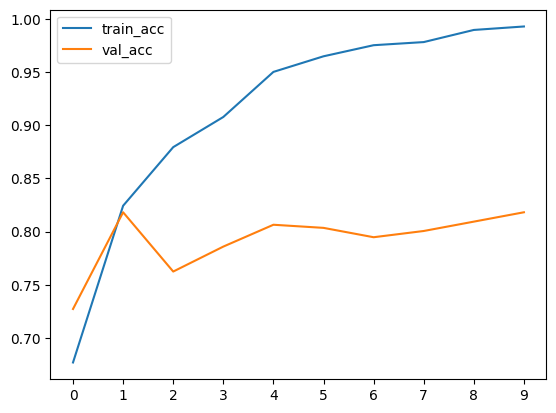

In [39]:
plt.plot(res.history['accuracy'], label='train_acc')
plt.plot(res.history['val_accuracy'], label='val_acc')
plt.xticks(np.arange(10))
plt.legend()

# Data augmentation

In [20]:
train_gen = ImageDataGenerator(

    preprocessing_function=preprocess_input,  # Apply Xception preprocessing

    rotation_range=30,        # Randomly rotate images up to 30 degrees

    width_shift_range=0.1,    # Random horizontal shift (10% of width)

    height_shift_range=0.1,   # Random vertical shift (10% of height)

    shear_range=0.1,          # Shear transformation

    zoom_range=0.2,           # Random zoom in/out (20%)

    horizontal_flip=True,     # Randomly flip images horizontally

    fill_mode='nearest'       # Fill empty pixels after transformations
)

train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small-master/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode = 'categorical'
)


Found 3068 images belonging to 10 classes.


In [21]:
learning_rate = 0.001

optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

loss = keras.losses.CategoricalCrossentropy()

model.compile(loss=loss, optimizer=optimizer, metrics=['accuracy'])

In [43]:
res = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.7549 - loss: 1.0125 - val_accuracy: 0.7977 - val_loss: 0.8505
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.7735 - loss: 0.9006 - val_accuracy: 0.8006 - val_loss: 0.8460
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.7832 - loss: 0.8449 - val_accuracy: 0.7918 - val_loss: 0.8897
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 96s 996ms/step - accuracy: 0.7836 - loss: 0.7997 - val_accuracy: 0.8094 - val_loss: 0.8261
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 95s 992ms/step - accuracy: 0.7934 - loss: 0.7440 - val_accuracy: 0.7918 - val_loss: 0.8051
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.8129 - loss: 0.6749 - val_accuracy: 0.8035 - val_loss: 0.7637
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.7982 - loss: 0.6593 - val_accuracy: 0.8094 - val_loss: 0.7874
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.8103 - loss: 0.6348 - val_accuracy: 0.8065 - 

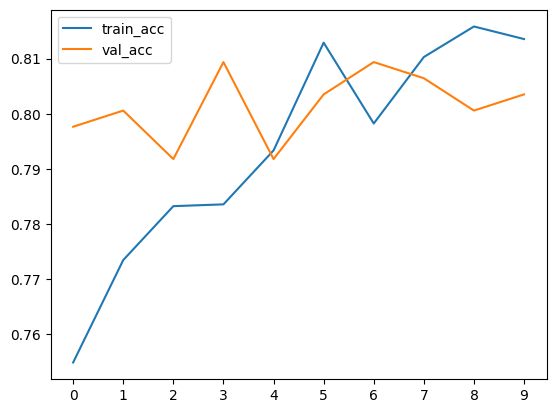

In [44]:
plt.plot(res.history['accuracy'], label='train_acc')
plt.plot(res.history['val_accuracy'], label='val_acc')
plt.xticks(np.arange(10))
plt.legend()

# Adding more layers
- Adding one inner dense layer
- Experimenting with different sizes of inner layer

In [22]:
def make_model(learning_rate=0.001, size_inner=100):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    
    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    
    outputs = keras.layers.Dense(10, activation='softmax')(inner)
    
    model = keras.Model(inputs, outputs)
    
    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy()

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )
    
    return model

In [22]:
scores = {}

for size in [100, 256]:
    print(size)

    model = make_model(size_inner=size)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[size] = history.history

    print()
    print()

100
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.5991 - loss: 1.1898 - val_accuracy: 0.7478 - val_loss: 0.7673
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 93s 973ms/step - accuracy: 0.6969 - loss: 0.8675 - val_accuracy: 0.7449 - val_loss: 0.7115
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 94s 978ms/step - accuracy: 0.7448 - loss: 0.7509 - val_accuracy: 0.7801 - val_loss: 0.6276
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 93s 969ms/step - accuracy: 0.7709 - loss: 0.6715 - val_accuracy: 0.7683 - val_loss: 0.6567
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.7705 - loss: 0.6786 - val_accuracy: 0.7947 - val_loss: 0.6068
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.7894 - loss: 0.6017 - val_accuracy: 0.7771 - val_loss: 0.6285
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.8051 - loss: 0.5682 - val_accuracy: 0.7801 - val_loss: 0.6843
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 94s 979ms/step - accuracy: 0.8067 - loss: 0.5639 - val_accuracy: 0

In [23]:
score = {}

for size in [256]:
    print(size)

    model = make_model(size_inner=size)
    history = model.fit(train_ds, epochs=20, validation_data=val_ds)
    score[size] = history.history

    print()
    print()

256
Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 100s 992ms/step - accuracy: 0.5975 - loss: 1.1964 - val_accuracy: 0.7478 - val_loss: 0.7302
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 94s 974ms/step - accuracy: 0.7102 - loss: 0.8474 - val_accuracy: 0.7889 - val_loss: 0.6727
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 93s 967ms/step - accuracy: 0.7357 - loss: 0.7681 - val_accuracy: 0.7859 - val_loss: 0.6528
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 92s 958ms/step - accuracy: 0.7647 - loss: 0.6829 - val_accuracy: 0.7918 - val_loss: 0.6546
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 92s 960ms/step - accuracy: 0.7806 - loss: 0.6208 - val_accuracy: 0.7801 - val_loss: 0.6514
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 93s 969ms/step - accuracy: 0.7950 - loss: 0.5814 - val_accuracy: 0.7830 - val_loss: 0.6511
Epoch 7/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 92s 955ms/step - accuracy: 0.7969 - loss: 0.5692 - val_accuracy: 0.7713 - val_loss: 0.7019
Epoch 8/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 93s 970ms/step - accuracy: 0.8119 - loss: 0.5352 - val

NameError: name 'scores' is not defined

In [24]:
plt.plot(score[256]['accuracy'], label='train_acc')
plt.plot(score[256]['val_accuracy'], label='val_acc')
plt.xticks(np.arange(20))

KeyError: 256

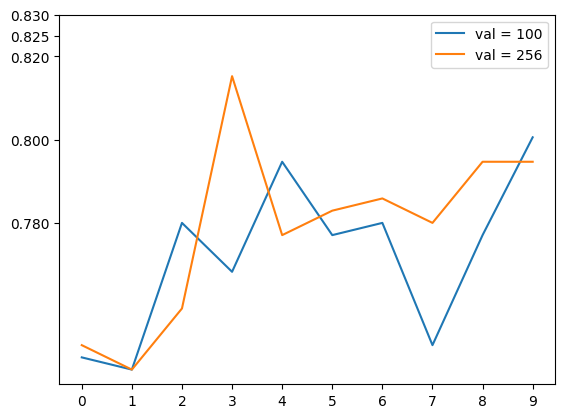

In [24]:
for size, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=(f'val = {size}'))

plt.xticks(np.arange(10))
plt.yticks([0.78, 0.80, 0.82, 0.825, 0.83])
plt.legend()

# Dropout 
- Regularizing by freezing a part of the network
- Adding dropout to our model
- Experimenting with different values

In [23]:
def make_model(learning_rate=0.001, size_inner=100, droprate=0.5):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    x = keras.layers.BatchNormalization()(vectors)
    inner = keras.layers.Dense(size_inner, activation='relu')(x)
    drop = keras.layers.Dropout(droprate)(inner)
    
    outputs = keras.layers.Dense(10, activation='softmax')(drop)
    
    model = keras.Model(inputs, outputs)
    
    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy()

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )
    
    return model

In [ ]:
scores = {}
for droprate in [0.2, 0.5]:
    print(droprate)

    model = make_model(
        droprate=droprate
    )

    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[droprate] = history.history

    print()
    print()

0.2
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 97s 968ms/step - accuracy: 0.5691 - loss: 1.4206 - val_accuracy: 0.7449 - val_loss: 0.8173
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 92s 954ms/step - accuracy: 0.6822 - loss: 0.9789 - val_accuracy: 0.7537 - val_loss: 0.7092
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 92s 958ms/step - accuracy: 0.7151 - loss: 0.8544 - val_accuracy: 0.7713 - val_loss: 0.6658
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 92s 962ms/step - accuracy: 0.7441 - loss: 0.7637 - val_accuracy: 0.7977 - val_loss: 0.6402
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 91s 951ms/step - accuracy: 0.7725 - loss: 0.6628 - val_accuracy: 0.7683 - val_loss: 0.6917
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.7663 - loss: 0.6623 - val_accuracy: 0.7801 - val_loss: 0.6836
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.7836 - loss: 0.6339 - val_accuracy: 0.7801 - val_loss: 0.6731
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 95s 992ms/step - accuracy: 0.7956 - loss: 0.5877 - val_accura

In [ ]:
for size, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=('val=%s' % size))

plt.xticks(np.arange(10))
plt.legend()

# Training a larger model

- Train a 299x299 model

In [24]:
def make_model(input_size=150, learning_rate=0.01, size_inner=100,
               droprate=0.5):

    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(input_size, input_size, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(input_size, input_size, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    
    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)
    
    outputs = keras.layers.Dense(10)(drop)
    
    model = keras.Model(inputs, outputs)
    
    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )
    
    return model

In [25]:
input_size = 299

In [27]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small-master/train',
    target_size=(input_size, input_size),
    batch_size=32
)


val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    './clothing-dataset-small-master/validation',
    target_size=(input_size, input_size),
    batch_size=32,
    shuffle=False
)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [28]:
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v4_1_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [ ]:
learning_rate = 0.0005
size = 100
droprate = 0.2

model = make_model(
    input_size=input_size,
    learning_rate=learning_rate,
    size_inner=size,
    droprate=droprate
)

history = model.fit(train_ds, epochs=50, validation_data=val_ds,
                   callbacks=[checkpoint])

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5432 - loss: 1.4865

96/96 ━━━━━━━━━━━━━━━━━━━━ 401s 4s/step - accuracy: 0.6724 - loss: 1.0652 - val_accuracy: 0.8358 - val_loss: 0.5527
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8084 - loss: 0.5951

96/96 ━━━━━━━━━━━━━━━━━━━━ 389s 4s/step - accuracy: 0.8132 - loss: 0.5715 - val_accuracy: 0.8592 - val_loss: 0.4568
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8463 - loss: 0.4591

96/96 ━━━━━━━━━━━━━━━━━━━━ 394s 4s/step - accuracy: 0.8478 - loss: 0.4529 - val_accuracy: 0.8680 - val_loss: 0.3907
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 390s 4s/step - accuracy: 0.8634 - loss: 0.3965 - val_accuracy: 0.8563 - val_loss: 0.3913
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 392s 4s/step - accuracy: 0.8833 - loss: 0.3500 - val_accuracy: 0.8651 - val_loss: 0.3607
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8898 - loss: 0.3295

96/96 ━━━━━━━━━━━━━━━━━━━━ 389s 4s/step - accuracy: 0.8885 - loss: 0.3209 - val_accuracy: 0.8768 - val_loss: 0.3649
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 398s 4s/step - accuracy: 0.9003 - loss: 0.3046 - val_accuracy: 0.8680 - val_loss: 0.3476
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9140 - loss: 0.2711

96/96 ━━━━━━━━━━━━━━━━━━━━ 393s 4s/step - accuracy: 0.9032 - loss: 0.2859 - val_accuracy: 0.8827 - val_loss: 0.3613
Epoch 9/50
27/96 ━━━━━━━━━━━━━━━━━━━━ 4:07 4s/step - accuracy: 0.8947 - loss: 0.2697

# Testing the model

In [1]:
import tensorflow as tf
from tensorflow import keras

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.applications.xception import preprocess_input

In [3]:
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_ds = test_gen.flow_from_directory(
    './clothing-dataset-small-master/test',
    target_size=(299, 299),
    batch_size=32,
    shuffle=False
)


Found 372 images belonging to 10 classes.


In [5]:
model = keras.models.load_model('xception_v4_1_08_0.883.h5')

In [6]:
model.evaluate(test_ds)

12/12 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.9167 - loss: 0.2531


[0.25310251116752625, 0.9166666865348816]

In [24]:
path = r'C:\Users\RTC\Desktop\Deep Learning\clothing-dataset-small-master\test\shoes\2b54e651-5d43-4f24-9e9e-a58ce16d7c88.jpg'

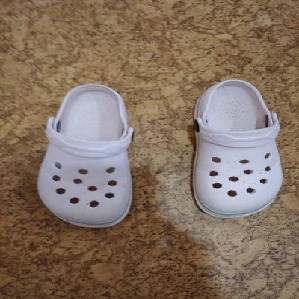

In [25]:
img = load_img(path, target_size=(299, 299))
img

In [26]:
import numpy as np

x = np.array(img)
print(x.shape)
X = np.array([x])
print(X.shape)

(299, 299, 3)
(1, 299, 299, 3)


In [27]:
X = preprocess_input(X)

In [28]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


In [29]:
pred_class = np.argmax(pred, axis=1)

print(pred_class)

[6]


In [30]:
classes = [
    'dress',
    'hat',
    'longsleeve',
    'outwear',
    'pants',
    'shirt',
    'shoes',
    'shorts',
    'skirt',
    't-shirt'
]

In [31]:
dict(zip(classes, pred[0]))

{'dress': np.float32(-2.2975905),
 'hat': np.float32(1.1188117),
 'longsleeve': np.float32(-4.518166),
 'outwear': np.float32(-1.7789979),
 'pants': np.float32(-1.481404),
 'shirt': np.float32(-1.622473),
 'shoes': np.float32(9.168631),
 'shorts': np.float32(-2.280685),
 'skirt': np.float32(-4.485768),
 't-shirt': np.float32(-3.9001248)}